In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)

In [4]:
df = pd.read_csv("Telco-Customer-Churn.csv")

In [5]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.drop("customerID", axis = 1, inplace = True)

In [7]:
df.duplicated().sum()

np.int64(22)

In [8]:
df.drop_duplicates(inplace = True)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.info()

<class 'pandas.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   str    
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   str    
 3   Dependents        7021 non-null   str    
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   str    
 6   MultipleLines     7021 non-null   str    
 7   InternetService   7021 non-null   str    
 8   OnlineSecurity    7021 non-null   str    
 9   OnlineBackup      7021 non-null   str    
 10  DeviceProtection  7021 non-null   str    
 11  TechSupport       7021 non-null   str    
 12  StreamingTV       7021 non-null   str    
 13  StreamingMovies   7021 non-null   str    
 14  Contract          7021 non-null   str    
 15  PaperlessBilling  7021 non-null   str    
 16  PaymentMethod     7021 non-null   str    
 17  MonthlyChar

In [11]:
df[df['TotalCharges'] == ' ']

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [12]:
df['TotalCharges'] = df['TotalCharges'].str.replace(' ', '0').astype(float)

In [13]:
df[df['TotalCharges'] == 0]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,0.0,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,0.0,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,0.0,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,0.0,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,0.0,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,0.0,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,0.0,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,0.0,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,0.0,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,0.0,No


In [14]:
df.info()

<class 'pandas.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   str    
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   str    
 3   Dependents        7021 non-null   str    
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   str    
 6   MultipleLines     7021 non-null   str    
 7   InternetService   7021 non-null   str    
 8   OnlineSecurity    7021 non-null   str    
 9   OnlineBackup      7021 non-null   str    
 10  DeviceProtection  7021 non-null   str    
 11  TechSupport       7021 non-null   str    
 12  StreamingTV       7021 non-null   str    
 13  StreamingMovies   7021 non-null   str    
 14  Contract          7021 non-null   str    
 15  PaperlessBilling  7021 non-null   str    
 16  PaymentMethod     7021 non-null   str    
 17  MonthlyChar

In [15]:
for col in df.columns:
    print(f"{col}: {df[col].unique()}")
    print("=" * 50)

gender: <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
SeniorCitizen: [0 1]
Partner: <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines: <ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService: <ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity: <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup: <ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection: <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport: <ArrowS

In [16]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({1: 'Yes', 0: 'No'})

In [17]:
df.info()

<class 'pandas.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   str    
 1   SeniorCitizen     7021 non-null   str    
 2   Partner           7021 non-null   str    
 3   Dependents        7021 non-null   str    
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   str    
 6   MultipleLines     7021 non-null   str    
 7   InternetService   7021 non-null   str    
 8   OnlineSecurity    7021 non-null   str    
 9   OnlineBackup      7021 non-null   str    
 10  DeviceProtection  7021 non-null   str    
 11  TechSupport       7021 non-null   str    
 12  StreamingTV       7021 non-null   str    
 13  StreamingMovies   7021 non-null   str    
 14  Contract          7021 non-null   str    
 15  PaperlessBilling  7021 non-null   str    
 16  PaymentMethod     7021 non-null   str    
 17  MonthlyChar

In [18]:
for col in df.select_dtypes(include = 'str').columns:
    df[col] = df[col].astype('category')

df.info()

<class 'pandas.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            7021 non-null   category
 1   SeniorCitizen     7021 non-null   category
 2   Partner           7021 non-null   category
 3   Dependents        7021 non-null   category
 4   tenure            7021 non-null   int64   
 5   PhoneService      7021 non-null   category
 6   MultipleLines     7021 non-null   category
 7   InternetService   7021 non-null   category
 8   OnlineSecurity    7021 non-null   category
 9   OnlineBackup      7021 non-null   category
 10  DeviceProtection  7021 non-null   category
 11  TechSupport       7021 non-null   category
 12  StreamingTV       7021 non-null   category
 13  StreamingMovies   7021 non-null   category
 14  Contract          7021 non-null   category
 15  PaperlessBilling  7021 non-null   category
 16  PaymentMethod     7021 non-null   catego

In [19]:
df['Churn'].value_counts(normalize = True)

# class in imbalance

Churn
No     0.735508
Yes    0.264492
Name: proportion, dtype: float64

**Insight**
1. Removed CustomerID column because it does not required for modelling.
2. No missing values in dataset.
3. Removed 22 duplicated rows.
4. Target class is imbalanced.

In [20]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7021.000000,7021.000000,7021.000000
mean,32.469449,64.851894,2286.765026
std,24.534965,30.069001,2266.855057
min,0.000000,18.250000,0.000000
25%,9.000000,35.750000,403.350000
50%,29.000000,70.400000,1400.550000
75%,55.000000,89.900000,3801.700000
max,72.000000,118.750000,8684.800000


In [21]:
def plot_histogram(df, col_name):
    fig, ax = plt.subplots(figsize = (5,3))
    sns.histplot(df[col_name], kde = True, ax= ax, palette= 'Set2')
    ax.set(xlabel= col_name, ylabel = 'Count', title = f'Histogram of {col_name}')
    plt.show()

In [22]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

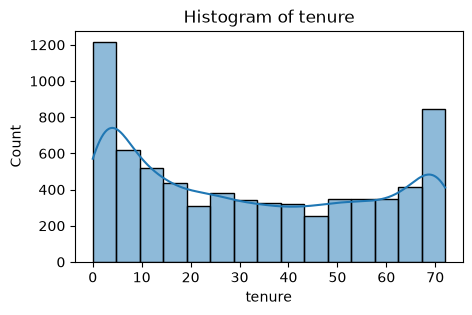

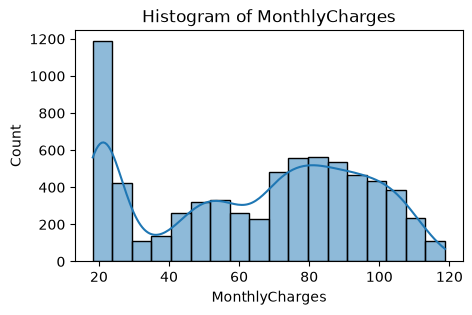

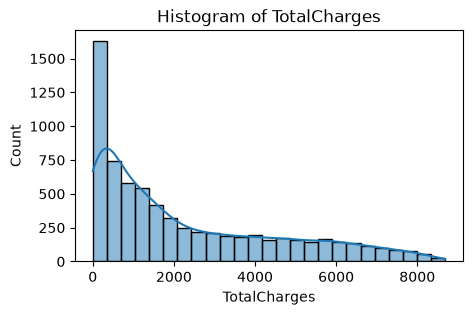

In [23]:
for col in numerical_cols:
    plot_histogram(df, col)

In [24]:
def plot_boxplot(df, col_name):
    plt.figure(figsize=(6, 4))
    sns.boxplot(df[col_name], palette = 'Pastel1')
    plt.title(f"Distribution of {col_name}")
    plt.xlabel(col_name)
    plt.ylabel("Value")
    plt.show()
    

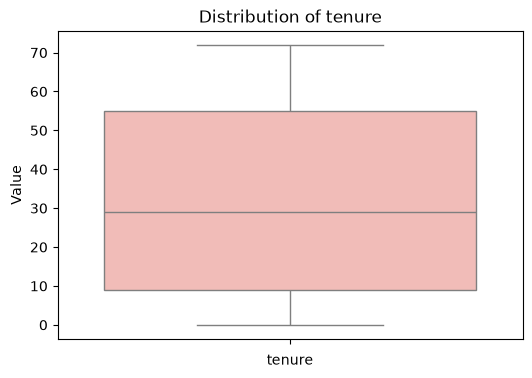

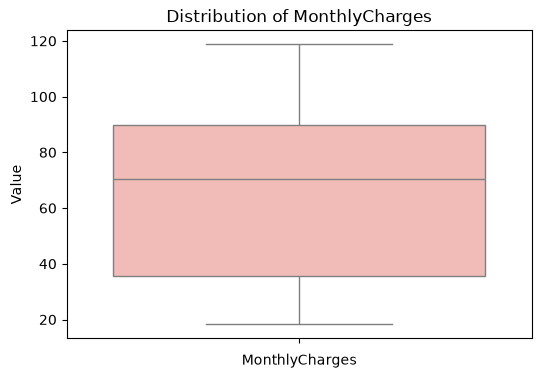

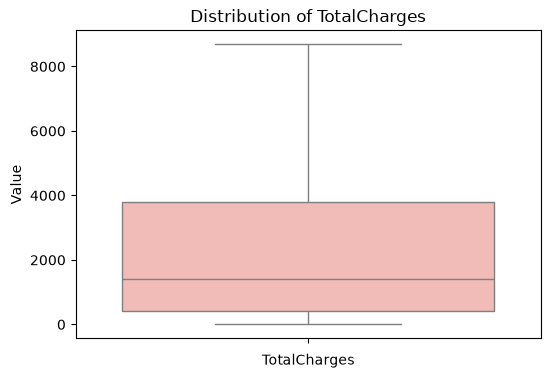

In [25]:
for col in numerical_cols:
    plot_boxplot(df, col)

**Insight**
1. Does not has outliers.

<Figure size 300x200 with 0 Axes>

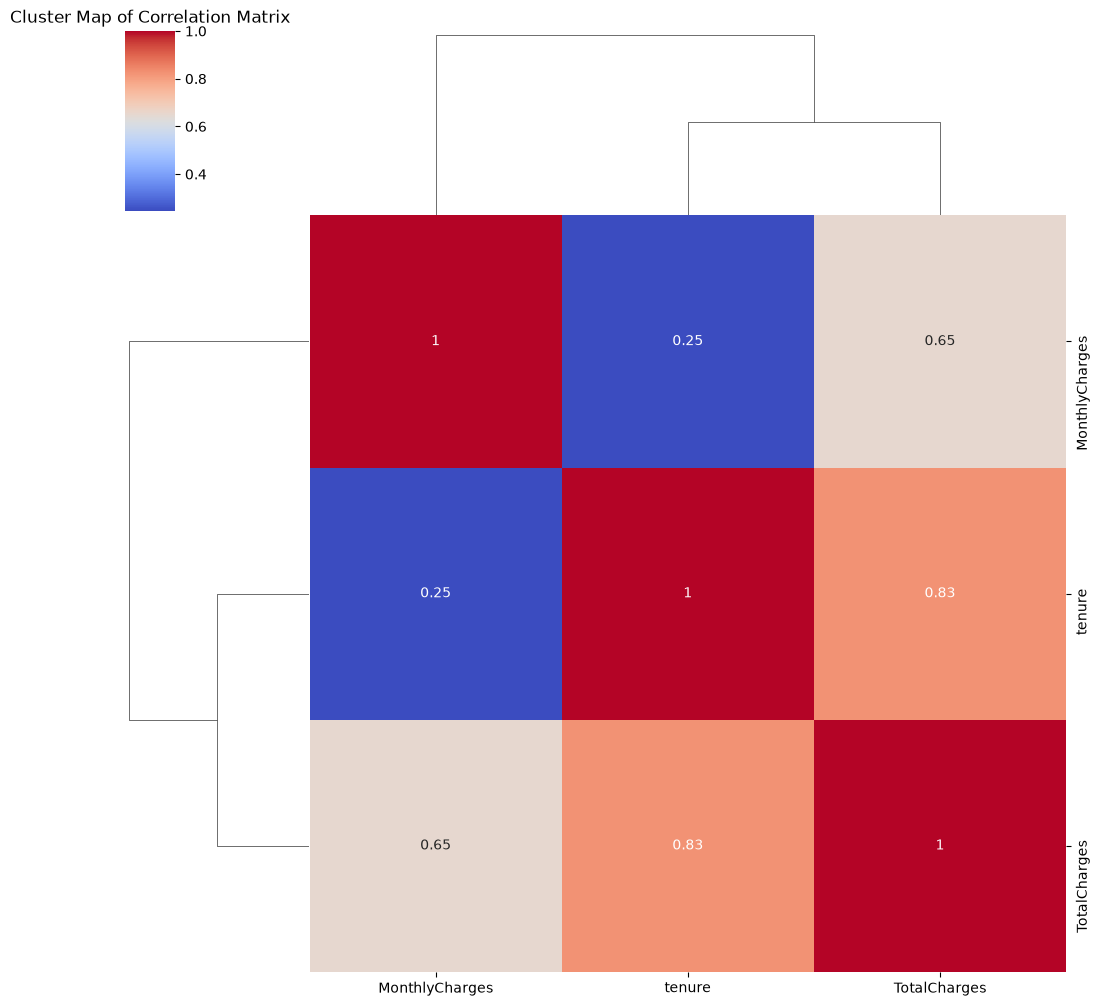

In [26]:
plt.figure(figsize = (3,2))
sns.clustermap(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(), annot = True, cmap= 'coolwarm')
plt.title("Cluster Map of Correlation Matrix", loc = 'center')
plt.show()

In [27]:
churn= df.groupby('Churn')['MonthlyCharges'].mean()

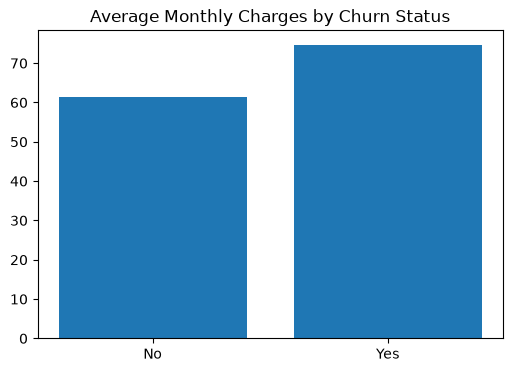

In [28]:
plt.figure(figsize = (6,4))
plt.bar(churn.index, churn.values)
plt .title("Average Monthly Charges by Churn Status")
plt.show()

In [29]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [30]:
df.groupby('Churn')['StreamingTV'].value_counts()*100/len(df)

Churn  StreamingTV        
No     Yes                    26.961971
       No                     26.605897
       No internet service    19.982908
Yes    No                     13.302948
       Yes                    11.593790
       No internet service     1.552485
Name: count, dtype: float64

In [31]:
df.drop(columns = {'gender', 'Dependents', 'Partner', 'TotalCharges', 'StreamingTV', 'PhoneService'}, inplace = True)

In [32]:
df.info()

<class 'pandas.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   SeniorCitizen     7021 non-null   category
 1   tenure            7021 non-null   int64   
 2   MultipleLines     7021 non-null   category
 3   InternetService   7021 non-null   category
 4   OnlineSecurity    7021 non-null   category
 5   OnlineBackup      7021 non-null   category
 6   DeviceProtection  7021 non-null   category
 7   TechSupport       7021 non-null   category
 8   StreamingMovies   7021 non-null   category
 9   Contract          7021 non-null   category
 10  PaperlessBilling  7021 non-null   category
 11  PaymentMethod     7021 non-null   category
 12  MonthlyCharges    7021 non-null   float64 
 13  Churn             7021 non-null   category
dtypes: category(12), float64(1), int64(1)
memory usage: 247.6 KB


In [33]:
X= df.drop(columns= ['Churn'])
y = df['Churn']

In [34]:
X

,SeniorCitizen,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges
0,No,1,No phone service,DSL,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,29.85
1,No,34,No,DSL,Yes,No,Yes,No,No,One year,No,Mailed check,56.95
2,No,2,No,DSL,Yes,Yes,No,No,No,Month-to-month,Yes,Mailed check,53.85
3,No,45,No phone service,DSL,Yes,No,Yes,Yes,No,One year,No,Bank transfer (automatic),42.30
4,No,2,No,Fiber optic,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,No,24,Yes,DSL,Yes,No,Yes,Yes,Yes,One year,Yes,Mailed check,84.80
7039,No,72,Yes,Fiber optic,No,Yes,Yes,No,Yes,One year,Yes,Credit card (automatic),103.20
7040,No,11,No phone service,DSL,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.60
7041,Yes,4,Yes,Fiber optic,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40


In [35]:
y

0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: Churn, Length: 7021, dtype: category
Categories (2, str): ['No', 'Yes']

In [36]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report, recall_score, confusion_matrix

In [37]:
y = y.map({'Yes': 1, 'No': 0})

In [38]:
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7021, dtype: category
Categories (2, int64): [0, 1]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

In [40]:
cat_cols = X_train.select_dtypes(include = 'category').columns
num_cols = ['tenure', 'MonthlyCharges']

In [41]:
# preprocessor = ColumnTransformer(transformers=[
#     ("cat", OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
#     ("num", StandardScaler(), num_cols)
# ])

# experiments = {
#     'XGBoost': {
#         'model': XGBClassifier(
#             n_estimators=150, 
#             scale_pos_weight=2.77, 
#             random_state=42
#         ),
#         'params': {
#             'classifier__max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
#             'classifier__learning_rate': [0.04, 0.05, 0.06, 0.07, 0.09, 0.1, 0.2, 0.4, 0.5]
#         }
#     },
#     'Decision Tree': {
#         'model': DecisionTreeClassifier(random_state=42),
#         'params': {
#             'classifier__criterion': ['gini', 'entropy', 'logloss'],
#             'classifier__splitter': ['best', 'random'],
#             'classifier__max_depth': [None, 3, 4, 5, 6, 7, 8, 9, 10] 
#         }
#     }
# }


In [42]:
# for model_name, instance in experiments.items():
#     print(instance['model'])

In [43]:
# best_models = {}

# for name, config in experiments.items():
#     print(f"================ Running {name} ================")
    
#     pipe = ImbPipeline(steps=[
#         ('preprocessor', preprocessor),
#         ('smote', SMOTE(random_state=42)),
#         ('classifier', config['model'])
#     ])

#     search = RandomizedSearchCV(
#         estimator=pipe,
#         param_distributions=config['params'],
#         cv=5,
#         scoring='recall',
#         n_iter=10,
#         n_jobs=-1,
#         random_state=42,
#         verbose=1
#     )

#     search.fit(X_train, y_train)
#     best_models[name] = search.best_estimator_

#     y_pred = search.predict(X_test)

#     print(f"\nBest Params for {name}: {search.best_params_}")
#     print(f"Classification Report ({name}):\n{classification_report(y_test, y_pred)}")
#     print(f"Test Recall: {recall_score(y_test, y_pred):.4f}")
#     print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

In [44]:
preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ("num", StandardScaler(), num_cols)
])

model = XGBClassifier(
    n_estimators=150, 
    scale_pos_weight=2.77, 
    random_state=42
)

pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', model)
])

In [46]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    'classifier__max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'classifier__learning_rate': [0.04, 0.05, 0.06, 0.07, 0.09, 0.1, 0.2, 0.4, 0.5]
}

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=params,
    cv=5,
    scoring='recall',
    n_iter=10,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

y_pred = best_model.predict(X_train)

print(f"\nBest Params: {search.best_params_}")
print(f"Classification Report :\n{classification_report(y_train, y_pred)}")
print(f"Recall: {recall_score(y_train, y_pred):.4f}")
print(f"Accuracy: {accuracy_score(y_train, y_pred):.4f}\n")
print(f"Confusion Matrix :\n{confusion_matrix(y_train, y_pred)}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Params: {'classifier__max_depth': 3, 'classifier__learning_rate': 0.04}
Classification Report :
              precision    recall  f1-score   support

           0       0.95      0.61      0.74      4131
           1       0.45      0.91      0.60      1485

    accuracy                           0.69      5616
   macro avg       0.70      0.76      0.67      5616
weighted avg       0.82      0.69      0.70      5616

Recall: 0.9091
Accuracy: 0.6861

Confusion Matrix :
[[2503 1628]
 [ 135 1350]]


In [47]:
y_test_pred = best_model.predict(X_test)


print(f"Classification Report :\n{classification_report(y_test, y_test_pred)}")
print(f"Recall :\n{recall_score(y_test, y_test_pred):.4f}")
print(f"Accuracy :\n{accuracy_score(y_test, y_test_pred):.4f}")
print(f"Confusion Matrix :\n{confusion_matrix(y_test, y_test_pred)}")

Classification Report :
              precision    recall  f1-score   support

           0       0.93      0.60      0.73      1033
           1       0.44      0.88      0.59       372

    accuracy                           0.67      1405
   macro avg       0.69      0.74      0.66      1405
weighted avg       0.80      0.67      0.69      1405

Recall :
0.8817
Accuracy :
0.6740
Confusion Matrix :
[[619 414]
 [ 44 328]]


In [ ]:
import pickle 

pickle.dump(df, open('df.pkl', 'wb'))
pickle.dump(best_model, open('model.pkl', 'wb'))